# **The Energy Imbalance Problem: Surface Energy Balance, Closure, and Corrections**

Why the fluxes measured at eddy-covariance towers do not add up, how large the gap is across the world's flux network, and how six different corrections redistribute it. Built from the methods and results of Raghav et al. (2026, AmeriFlux Annual Meeting) and Raghav & Kumar (2026).

## **Learning objectives**

By the end of this tutorial you will be able to:

- Write the surface energy balance and compute the evaporative fraction, Bowen ratio, and energy balance ratio.
- Describe the size and pattern of the energy imbalance across the global flux network.
- Diagnose closure at one site by season, wetness, time of day, and year.
- Apply five closure corrections (Bowen ratio, OFC, MDEBR, PULSE, FLARE) to half-hourly data and explain what each assumes.
- Quantify how much the choice of correction changes evapotranspiration, and judge which corrections are better supported.

**Before you start:** Basic Python (pandas, matplotlib). Runs in about two minutes.

## **1. The surface energy balance**

At the land surface, net radiation $R_n$ is the energy available. It evaporates water (latent heat flux, $LE$), warms
the air (sensible heat flux, $H$), and warms the soil (ground heat flux, $G$):

$$ R_n - G = LE + H \qquad (1) $$

with small additional terms for heat stored in the canopy air and biomass. Two ratios describe how the available energy
$R_n - G$ is partitioned:

- **Evaporative fraction:** $\;EF = \dfrac{LE}{LE + H}$
- **Bowen ratio:** $\;\beta = \dfrac{H}{LE}$

Over a wet surface most energy goes into $LE$ ($EF \to 1$, $\beta \to 0$). Over a dry surface $H$ dominates.

## **2. The energy imbalance problem**

Eddy-covariance towers measure $H$ and $LE$ directly from the covariance of vertical wind speed with temperature and
humidity. Net radiation and ground heat flux are measured independently. When we compare $H + LE$ with $R_n - G$, the
turbulent fluxes are almost always **smaller** than the available energy, typically by 10 to 30%. The ratio

$$ EBR = \frac{\sum (H + LE)}{\sum (R_n - G)} \qquad (2) $$

is the **energy balance ratio**. Across the global flux network it looks like this:

![Global flux network closure](https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/tutorials/assets/EBC_global_flux_network_closure.png)

*Figure 1. (a) 980 flux sites of FLUXNET, AmeriFlux, ICOS, OzFlux and JapanFlux. (b) Site-mean turbulent flux against
available energy at 839 sites: the slope is 0.73. (c) The energy-balance ratio by land cover; the median site closes at
0.83, and 87% of sites are below 1. Source: Raghav et al. (2026), AmeriFlux Annual Meeting.*

The gap is not random noise. It is systematic, it is larger at some land covers (wetlands, croplands) than others, and it
has several suspected causes: large-scale eddies and secondary circulations that a single tower does not sample, mismatch
between the footprint of the flux measurement and that of the radiometer and soil sensors, unmeasured storage terms, and
instrument errors. Whichever cause dominates, the practical question for anyone using the data is:

> **Where did the missing energy go: into $LE$, into $H$, or into neither?**

Every closure correction is one answer to that question. The choice matters because evapotranspiration from these towers
is the benchmark for satellite ET products, land surface models, and water budgets.

## **3. Closure at one site: US-Var, daily data**

**Site:** US-Var (Vaira Ranch, California), an AmeriFlux grassland with wet, mild winters and dry, hot summers. The daily
file has gap-filled fluxes, net radiation, meteorology, LAI, GPP, and soil moisture for 2000-2021. Fluxes are daily
means in W m$^{-2}$.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv', 'US-Var_halfhourly_2018_2019.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv',
 'US-Var_halfhourly_2018_2019.csv': '..\\..\\sample_data\\US-Var_halfhourly_2018_2019.csv'}

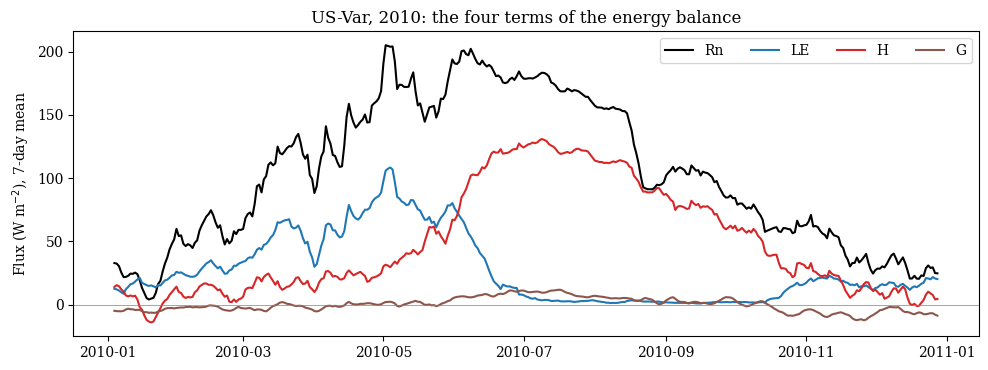

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA', 'VPD_F': 'VPD'})
df['EF'] = df['LE'] / (df['LE'] + df['H']); df['Bowen'] = df['H'] / df['LE']
ok = (df['Rn'] - df['G'] > 20) & (df['LE'] > 0) & (df['H'] > -20)      # days with meaningful available energy

yr = df.loc['2010']
fig, ax = plt.subplots(figsize=(10, 3.8))
for col, c in zip(['Rn', 'LE', 'H', 'G'], ['k', 'tab:blue', 'tab:red', 'tab:brown']):
    ax.plot(yr.index, yr[col].rolling(7, center=True).mean(), label=col, color=c)
ax.set_ylabel('Flux (W m$^{-2}$), 7-day mean'); ax.set_title('US-Var, 2010: the four terms of the energy balance'); ax.axhline(0, color='grey', lw=0.5); ax.legend(ncol=4); plt.tight_layout()

In winter and spring the grassland is green and the soil is wet, so $LE$ is large. From June on the grass dies and the
soil dries; $LE$ collapses and almost all available energy goes into $H$. Energy and water are out of phase, the signature
of a Mediterranean climate.

### **3.1 How well do the fluxes close?**

OLS slope = 0.71, intercept = 7.6 W m-2, R2 = 0.86
Energy balance ratio = 0.79: turbulent fluxes are 21% short of available energy


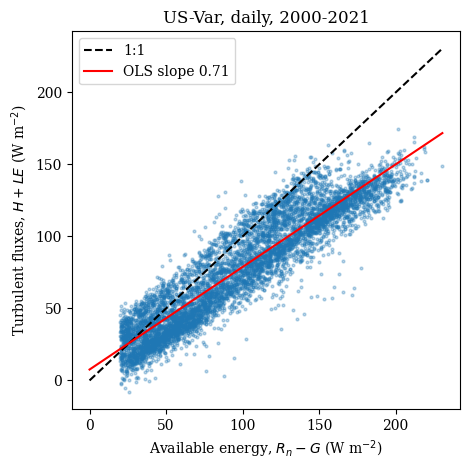

In [3]:
x = (df['Rn'] - df['G']).loc[ok]; y = (df['LE'] + df['H']).loc[ok]
slope, intercept = np.polyfit(x, y, 1); ebr = y.sum() / x.sum()
print(f'OLS slope = {slope:.2f}, intercept = {intercept:.1f} W m-2, R2 = {np.corrcoef(x, y)[0, 1]**2:.2f}')
print(f'Energy balance ratio = {ebr:.2f}: turbulent fluxes are {100*(1-ebr):.0f}% short of available energy')
fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.scatter(x, y, s=4, alpha=0.3); lim = [0, max(x.max(), y.max())]
ax.plot(lim, lim, 'k--', label='1:1'); ax.plot(lim, np.polyval([slope, intercept], lim), 'r-', label=f'OLS slope {slope:.2f}')
ax.set_xlabel('Available energy, $R_n - G$ (W m$^{-2}$)'); ax.set_ylabel('Turbulent fluxes, $H + LE$ (W m$^{-2}$)'); ax.legend(); ax.set_title('US-Var, daily, 2000-2021'); plt.tight_layout()

### **3.2 Does closure depend on season, wetness, or year?**

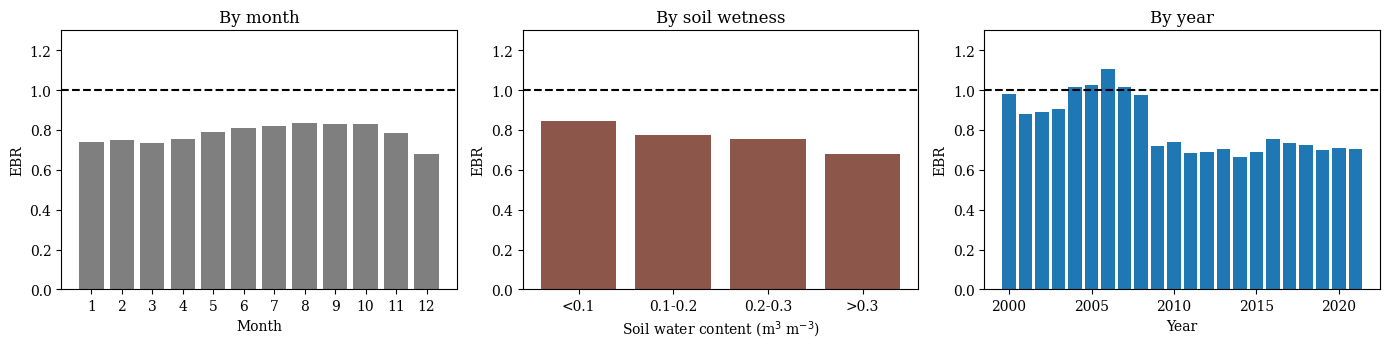

In [4]:
tmp = df.loc[ok, ['Rn', 'G', 'LE', 'H', 'theta_2']].copy(); tmp['month'] = tmp.index.month
ratio = lambda g: (g['LE'] + g['H']).sum() / (g['Rn'] - g['G']).sum()
ebr_m = tmp.groupby('month').apply(ratio)
tmp['wet'] = pd.cut(tmp['theta_2'], [0, 0.1, 0.2, 0.3, 0.6], labels=['<0.1', '0.1-0.2', '0.2-0.3', '>0.3'])
ebr_w = tmp.groupby('wet', observed=True).apply(ratio)
ebr_y = tmp.groupby(tmp.index.year).apply(ratio)
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
axs[0].bar(ebr_m.index, ebr_m.values, color='tab:grey'); axs[0].set_xlabel('Month'); axs[0].set_title('By month'); axs[0].set_xticks(range(1, 13))
axs[1].bar(ebr_w.index.astype(str), ebr_w.values, color='tab:brown'); axs[1].set_xlabel('Soil water content (m$^3$ m$^{-3}$)'); axs[1].set_title('By soil wetness')
axs[2].bar(ebr_y.index, ebr_y.values, color='tab:blue'); axs[2].set_xlabel('Year'); axs[2].set_title('By year')
for ax in axs: ax.axhline(1, color='k', ls='--'); ax.set_ylim(0, 1.3); ax.set_ylabel('EBR')
plt.tight_layout()

**What to notice.** Closure changes with season and surface state, so one correction factor for all days would bias
the result. And it changes by year: the ratio drops from about 1.0 to about 0.7 between 2008 and 2009, when the net
radiometer was replaced. The ecosystem did not change; the instrument did. Look at the record before trusting an average.

## **4. Closure through the day: half-hourly data**

Daily means hide the diurnal structure of the imbalance. The file `US-Var_halfhourly_2018_2019.csv` holds two years of
half-hourly AmeriFlux BASE data for the same site (gap-filled LE, H, GPP, meteorology; measured $R_n$ and $G$).
Corrections are always applied at this native resolution and aggregated afterwards.

35040 half hours; measured (not gap-filled) LE on 72% of them
Overall daytime EBR, 2018-2019: 0.72


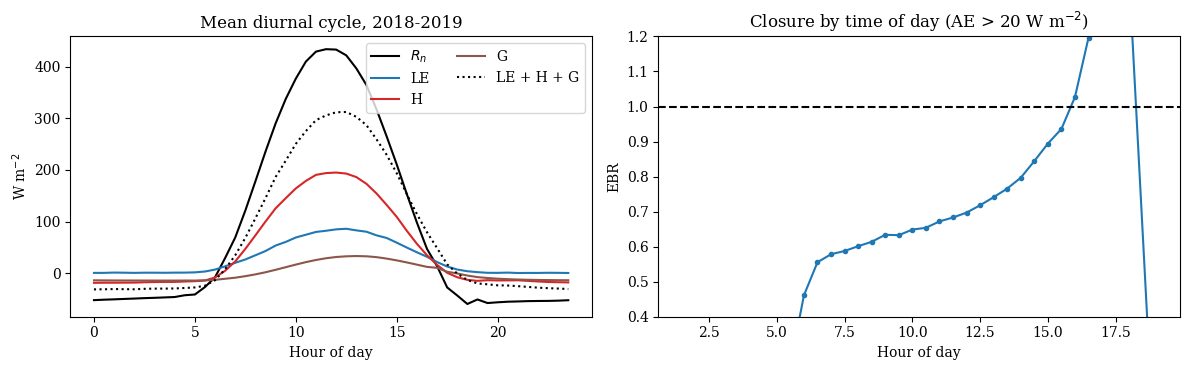

In [5]:
hh = pd.read_csv(paths['US-Var_halfhourly_2018_2019.csv'], parse_dates=['DateTime'])
hh['AE'] = hh['NETRAD'] - hh['G']
print(f'{len(hh)} half hours; measured (not gap-filled) LE on {100*hh["LE_measured_flag"].mean():.0f}% of them')
hh['hour'] = hh['DateTime'].dt.hour + hh['DateTime'].dt.minute / 60
diurnal = hh.groupby('hour')[['AE', 'LE', 'H', 'G', 'NETRAD']].mean()
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].plot(diurnal.index, diurnal['NETRAD'], 'k', label='$R_n$'); axs[0].plot(diurnal.index, diurnal['LE'], 'tab:blue', label='LE'); axs[0].plot(diurnal.index, diurnal['H'], 'tab:red', label='H'); axs[0].plot(diurnal.index, diurnal['G'], 'tab:brown', label='G')
axs[0].plot(diurnal.index, diurnal['LE'] + diurnal['H'] + diurnal['G'], 'k:', label='LE + H + G'); axs[0].set_xlabel('Hour of day'); axs[0].set_ylabel('W m$^{-2}$'); axs[0].legend(ncol=2); axs[0].set_title('Mean diurnal cycle, 2018-2019')
day = hh['AE'] > 20
ebr_h = hh[day].groupby('hour').apply(lambda g: (g['LE'] + g['H']).sum() / g['AE'].sum())
axs[1].plot(ebr_h.index, ebr_h.values, 'o-', ms=3); axs[1].axhline(1, color='k', ls='--'); axs[1].set_ylim(0.4, 1.2); axs[1].set_xlabel('Hour of day'); axs[1].set_ylabel('EBR'); axs[1].set_title('Closure by time of day (AE > 20 W m$^{-2}$)')
plt.tight_layout()
print(f"Overall daytime EBR, 2018-2019: {(hh.loc[day, 'LE'] + hh.loc[day, 'H']).sum() / hh.loc[day, 'AE'].sum():.2f}")

The gap opens in the morning and stays through the afternoon. Storage terms (heat going into the canopy air and biomass)
explain some of the morning gap and give it back in the evening, which is why some corrections treat the nighttime
residual as storage. The rest is the systematic underestimate the corrections try to repair.

## **5. Six answers to one question: where did the missing energy go?**

Each correction assigns some fraction $f$ of the residual $R_n - G - H - LE$ to $LE$ (and, for some, the rest to $H$).
The table follows the methods in Raghav et al. (2026); the fraction $f$ in the last column was measured across the
global network, not assumed.

| Benchmark | What it assumes | Class | $f$ (network) |
|---|---|---|---|
| **Original** | LE was measured right; the residual belongs to H or to nothing | uncorrected | 0.00 |
| **Bowen ratio** (Twine et al., 2000) | the measured H/LE is right; scale both so they add up, each half hour | forced closure | by $\beta$ |
| **OFC** (ONEFlux, Pastorello et al., 2020) | same idea with a smoothed factor from a moving 30-day window of stable hours | forced closure | 0.91 |
| **AEC** (Zhang et al., 2024) | the error scales with available energy; one site-level factor from the residual-AE covariance | forced closure | 0.28 |
| **MDEBR** (after Mauder et al., 2013) | nighttime residual is storage released by day; daytime fluxes divided by the daily ratio | forced closure | 0.64 |
| **PULSE** (Raghav & Kumar, 2026) | plant physiology sets an upper bound on water-use efficiency that a measurement error cannot exceed | independent constraint | 0.28 |
| **FLARE** (Raghav & Kumar, 2026, in review) | thermodynamics sets an equilibrium Bowen ratio; the observed H against it says how much LE is missing | independent constraint | 0.52 |

Forced-closure methods make $H + LE = R_n - G$ by construction. The two independent constraints do not; they use a
physical quantity that does not depend on the flux measurement to decide how much of the gap is latent heat.

**Bowen ratio.** With $\beta = H/LE$ assumed correct:
$$ LE_{corr} = \frac{R_n - G}{1 + \beta}, \qquad H_{corr} = \beta \, LE_{corr} \qquad (3) $$

**OFC.** The same, but the factor $EBC\_CF = (R_n - G)/(H + LE)$ is the median over a $\pm$15-day window of "stable"
half hours (22:00-02:30 and 10:00-14:30), after outlier removal. $H$ and $LE$ are both multiplied by it.

**MDEBR.** For each day, the nighttime residual $S_n = \sum_{night}(R_n - G - H - LE)$ is treated as storage. The
daytime ratio is $EBR_d = \sum_{day}(H + LE) \,/\, \left[\sum_{day}(R_n - G) + S_n\right]$, clipped to [0.3, 1.7], and
daytime $H$ and $LE$ are divided by it.

**PULSE.** The underlying water-use efficiency $uWUE = GPP\sqrt{VPD}/ET$ has an upper envelope, $uWUE_p$, set by plant
physiology. If $LE$ is underestimated, $ET$ is too small and $uWUE_p$ appears too high. So: estimate $uWUE_p$ on
near-closed half hours ($EBR$ in 0.9-1.1) as a reference; fit how the apparent $uWUE_p$ rises as $EBR$ falls (a LOESS
over $EBR$ bins); the ratio $CF = uWUE_p(EBR) / uWUE_{p,ref}$ is the factor by which $ET$ was underestimated.
$LE$ is multiplied by $CF$ (never decreased, capped at 5); $H$ is left alone.

**FLARE.** From the Clausius-Clapeyron relation, air near the surface tends toward an equilibrium Bowen ratio
$$ B_{eq} = \frac{R_v c_p T^2}{\lambda^2 q} \qquad (4) $$
($T$ air temperature in K, $q$ specific humidity, $\lambda$ latent heat). This gives an equilibrium partition
$H_{eq} = (R_n - G)\,B_{eq}/(1 + B_{eq})$ that does not use the flux measurement. The signal $H_{eq} / (R_n - G - LE)$ falls
below its near-closure value when $LE$ is underestimated; the fraction $1 - r$ of the actual gap is given to $LE$,
bounded by the gap and by $LE_{eq}$.

The module `ebc_corrections.py` implements all five (AEC needs its authors' package and is described only).

In [6]:
import importlib, sys
if not os.path.exists('ebc_corrections.py'):
    urllib.request.urlretrieve(BASE.replace('sample_data/', 'tutorials/process_hydrology/') + 'ebc_corrections.py', 'ebc_corrections.py')
sys.path.insert(0, '.'); import ebc_corrections as ebc; importlib.reload(ebc)

# daytime definition for MDEBR: potential (top-of-atmosphere) shortwave from solar geometry
hh['SW_IN_POT'] = ebc.potential_shortwave(hh['DateTime'], lat_deg=38.4133, lon_deg=-120.9507, utc_offset_h=-8)
corr = ebc.apply_all(hh)                   # adds LE_BR, LE_OFC, LE_MDEBR, LE_PULSE, LE_FLARE (+ H_* where the method changes H)
methods = ['LE', 'LE_BR', 'LE_OFC', 'LE_MDEBR', 'LE_PULSE', 'LE_FLARE']
labels = {'LE': 'Original', 'LE_BR': 'Bowen ratio', 'LE_OFC': 'OFC', 'LE_MDEBR': 'MDEBR', 'LE_PULSE': 'PULSE', 'LE_FLARE': 'FLARE'}
colors = {'LE': 'dimgrey', 'LE_BR': 'tab:purple', 'LE_OFC': 'tab:blue', 'LE_MDEBR': 'tab:green', 'LE_PULSE': 'goldenrod', 'LE_FLARE': 'orangered'}
print(corr[['CF_OFC', 'EBR_d', 'CF_PULSE', 'CF_FLARE']].describe().loc[['count', 'mean', '50%', 'min', 'max']].round(2))

         CF_OFC     EBR_d  CF_PULSE  CF_FLARE
count  35040.00  16899.00  14653.00  16654.00
mean       1.44      0.86      1.05      1.84
50%        1.45      0.83      1.00      1.10
min        1.13      0.30      1.00      1.00
max        1.63      1.70      1.88     25.26


### **5.1 One week in April: the same tower, six latent heat fluxes**

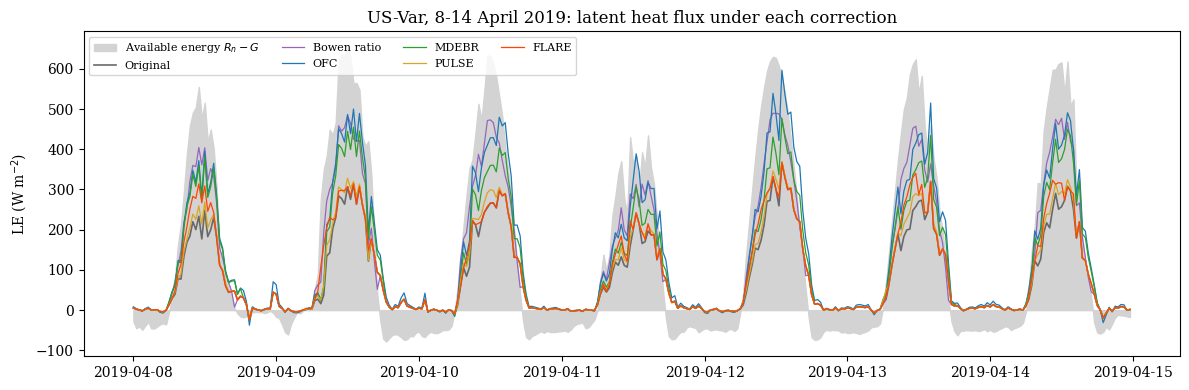

In [7]:
w = corr[(corr['DateTime'] >= '2019-04-08') & (corr['DateTime'] < '2019-04-15')]
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(w['DateTime'], 0, w['AE'], color='lightgrey', label='Available energy $R_n - G$')
for m in methods: ax.plot(w['DateTime'], w[m], color=colors[m], lw=1.2 if m == 'LE' else 0.9, label=labels[m])
ax.set_ylabel('LE (W m$^{-2}$)'); ax.legend(ncol=4, fontsize=8); ax.set_title('US-Var, 8-14 April 2019: latent heat flux under each correction'); plt.tight_layout()

### **5.2 How much of the gap does each method give to LE?**

In [8]:
day = corr['AE'] > 20
gap = (corr['AE'] - corr['H'] - corr['LE']).clip(lower=0)
rows = []
for m in methods[1:]:
    added = (corr[m] - corr['LE'])[day]
    rows.append({'method': labels[m], 'fraction of daytime gap to LE': added.sum() / gap[day].sum(),
                 'mean LE added (W/m2, daytime)': added.mean(), 'half hours changed (%)': 100 * (np.abs(corr[m] - corr['LE']) > 0.01)[day].mean()})
print(pd.DataFrame(rows).set_index('method').round(2))

             fraction of daytime gap to LE  mean LE added (W/m2, daytime)  \
method                                                                      
Bowen ratio                           0.29                          24.73   
OFC                                   0.35                          29.64   
MDEBR                                 0.20                          17.00   
PULSE                                 0.03                           2.17   
FLARE                                 0.28                          23.57   

             half hours changed (%)  
method                               
Bowen ratio                   94.61  
OFC                           99.97  
MDEBR                         99.53  
PULSE                         45.67  
FLARE                         74.82  


The methods disagree, and the disagreement is not about details. The Bowen-ratio family assigns the gap in proportion to
the measured partition; MDEBR assigns less because part of the gap is booked as storage; PULSE and FLARE assign what
their physical constraint says is missing, which at this dry, high-Bowen-ratio grassland is modest. Compare the numbers
with the network-wide $f$ values in the table: the site matters.

### **5.3 The residual and the Bowen ratio**

Across the global network, the corrections spread most where the Bowen ratio is low (wet, evaporating surfaces) and converge where it is high. See what happens at this one dry site.

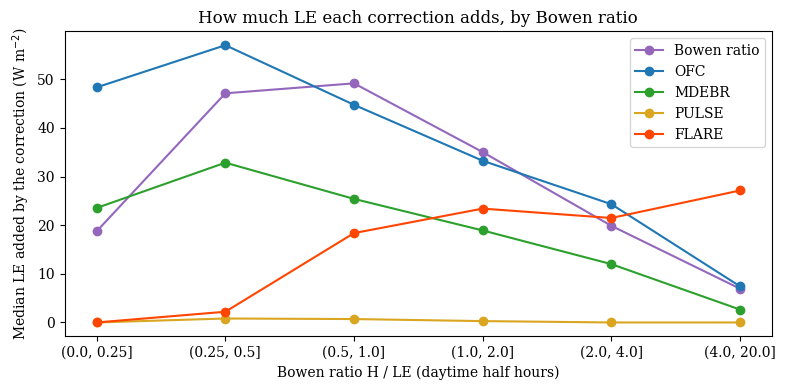

In [9]:
d = corr[day & (corr['LE'] > 5)].copy()
d['beta'] = d['H'] / d['LE']
d['beta_bin'] = pd.cut(d['beta'], [0, 0.25, 0.5, 1, 2, 4, 20])
fig, ax = plt.subplots(figsize=(8, 4))
for m in methods[1:]:
    added = (d[m] - d['LE']).groupby(d['beta_bin'], observed=True).median()
    ax.plot(range(len(added)), added.values, 'o-', color=colors[m], label=labels[m])
ax.set_xticks(range(len(added))); ax.set_xticklabels([str(i) for i in added.index], rotation=0)
ax.set_xlabel('Bowen ratio H / LE (daytime half hours)'); ax.set_ylabel('Median LE added by the correction (W m$^{-2}$)')
ax.legend(); ax.set_title('How much LE each correction adds, by Bowen ratio'); plt.tight_layout()

**What to notice.** The forced-closure methods (Bowen ratio, OFC, MDEBR) add the most latent heat at moderate Bowen
ratios, where LE is a large share of the turbulent flux, and little when the surface is dry. PULSE adds almost nothing
at this site: the water-use-efficiency envelope on near-closed periods is already consistent with the measured LE, so
the method finds no evidence that LE is missing. FLARE behaves differently: it adds most at high Bowen ratios, in the
dry summer, because the thermodynamic equilibrium partition allows more evaporation than the tower measures and the
method gives part of the gap to LE up to that bound. Whether a dry annual grassland really evaporates 0.5 mm/day in
August is a question the flux data alone cannot settle; it is exactly the kind of site-level check a user should make
before adopting any correction.

### **5.4 Daily and annual evapotranspiration**

Annual ET (mm):
      Original  Bowen ratio    OFC  MDEBR  PULSE  FLARE
date                                                   
2018     320.0        433.0  471.0  396.0  324.0  445.0
2019     373.0        507.0  547.0  478.0  392.0  493.0

Range across corrections: 347 to 509 mm, i.e. 47% of the original


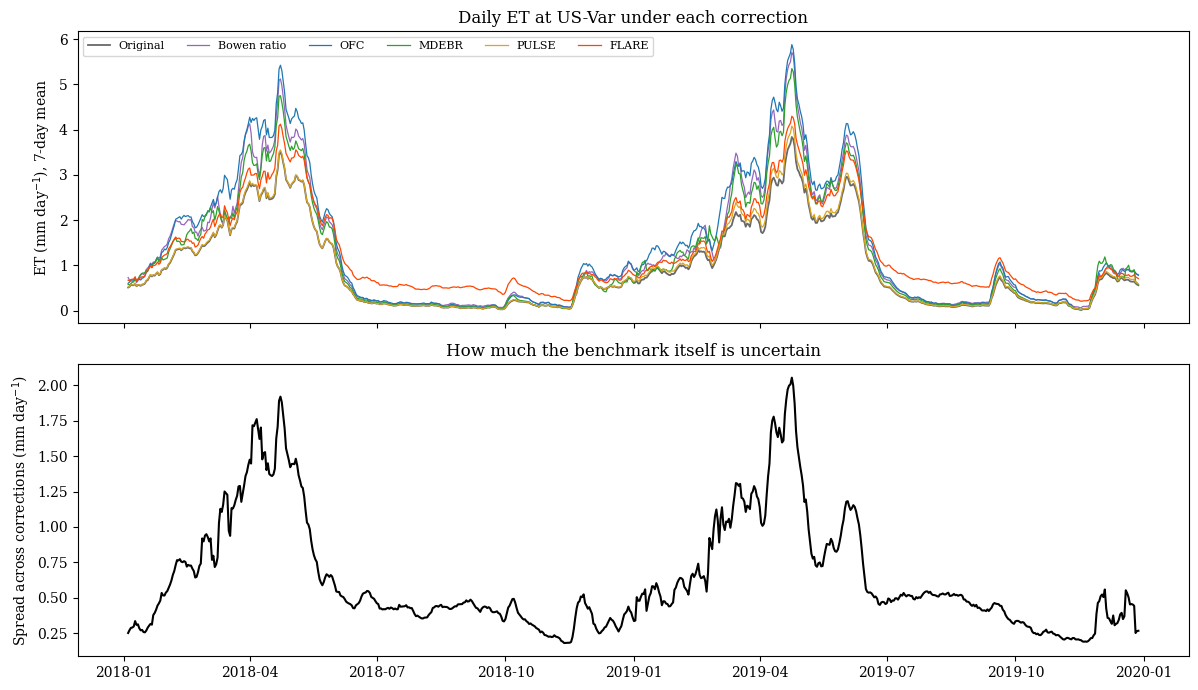

In [10]:
daily = ebc.daily_et_mm(corr)                       # mm/day, days with at least 75% of half hours
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for m in methods:
    c = m.replace('LE', 'ET'); axs[0].plot(daily.index, daily[c].rolling(7, center=True).mean(), color=colors[m], lw=1.3 if m == 'LE' else 0.9, label=labels[m])
axs[0].set_ylabel('ET (mm day$^{-1}$), 7-day mean'); axs[0].legend(ncol=6, fontsize=8); axs[0].set_title('Daily ET at US-Var under each correction')
spread = daily[[m.replace('LE', 'ET') for m in methods]].max(axis=1) - daily[[m.replace('LE', 'ET') for m in methods]].min(axis=1)
axs[1].plot(daily.index, spread.rolling(7, center=True).mean(), 'k'); axs[1].set_ylabel('Spread across corrections (mm day$^{-1}$)'); axs[1].set_title('How much the benchmark itself is uncertain')
plt.tight_layout()
ann = daily.resample('YE').sum(); ann.index = ann.index.year
ann.columns = [labels[c.replace('ET', 'LE')] for c in ann.columns]
print('Annual ET (mm):'); print(ann.round(0))
print('\nRange across corrections: %.0f to %.0f mm, i.e. %.0f%% of the original' % (ann.mean().min(), ann.mean().max(), 100 * (ann.mean().max() / ann.mean().min() - 1)))

## **6. Why this matters, and which correction to prefer**

Tower ET is the benchmark against which satellite ET products and land surface models are judged. If the benchmark
moves by 30 to 40% depending on a processing choice, the judgment moves with it. Across 425 sites and eight satellite ET
models, changing only the correction shifted a model's skill (KGE) by 0.19, compared with 0.24 between models, and the
best model changed at 81% of sites:

![Corrections change the benchmark](https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/tutorials/assets/EBC_corrections_change_ET_benchmark.png)

*Figure 2. (a) The same site-days give a median tower ET of 1.47 to 2.12 mm/day depending on the correction. (b-d)
Skill, error, and bias of eight satellite ET models scored against each benchmark; six of eight change the sign of
their bias. Source: Raghav et al. (2026).*

Where does it matter most? Wetlands, high-ET days, and winter; least in arid shrubland and savanna. Sites that close well
are least affected:

![Where it matters](https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/tutorials/assets/EBC_where_it_matters.png)

*Figure 3. (a) Range of model RMSE across the six benchmarks, as a percentage of each setting's RMSE. (b) The same range
per site against the site's energy-balance ratio. Source: Raghav et al. (2026).*

**Which correction should you use?** There is no closed-form answer, because transpiration is not measured
independently at the tower. Two indirect tests help. First, a physically coherent flux should be predictable from
meteorology alone; a network trained on the corrected flux should generalize to unseen sites, droughts, and heat waves.
Second, the maximum stomatal conductance inferred from the corrected flux should not depend on how well the site
happened to close. On both tests across the global network, FLARE and PULSE ranked highest, MDEBR was the best of the
forced-closure methods, and forcing closure with the measured Bowen ratio made the fluxes *less* coherent than leaving
them uncorrected. Whatever you choose, report it, and carry the spread across methods as part of the uncertainty.

## **Exercises**

**Exercise 1.** Compute the energy balance ratio for 2018 and 2019 separately from the half-hourly data, for daytime (AE > 20) and nighttime. Why is the nighttime ratio not meaningful in the same way?

**Exercise 2.** The Bowen-ratio correction is unstable when $\beta \to -1$. Count how many half hours in the record have $-1.5 < \beta < -0.5$ and plot when they occur. What is happening physically at those times?

**Exercise 3.** Implement the simplest possible alternative: give the entire residual to LE. Add it to the comparison in 5.2 and 5.4. Under what conditions is it a defensible choice?

**Exercise 4.** PULSE corrects only where the closure level lowers the apparent $uWUE_p$. Plot `uWUEp_pred` against `EBR` for 2019 (the LOESS the method fits). Does the curve slope the way the method expects?

**Exercise 5.** FLARE relies on the equilibrium Bowen ratio $B_{eq}$. Plot `B_eq` against the observed $\beta$ for daytime half hours. Where the observed $\beta$ is far below $B_{eq}$, what does the method do, and why is that a limitation in wet ecosystems?

**Exercise 6.** Apply the corrections to the daily file instead (treat each day as one interval). Compare the annual ET with the half-hourly results and explain why the order of aggregation and correction matters.

## **References**

- Twine, T. E., et al. (2000). Correcting eddy-covariance flux underestimates over a grassland. *Agricultural and Forest Meteorology*, 103, 279-300.
- Wilson, K., et al. (2002). Energy balance closure at FLUXNET sites. *Agricultural and Forest Meteorology*, 113, 223-243.
- Mauder, M., et al. (2013). A strategy for quality and uncertainty assessment of long-term eddy-covariance measurements. *Agricultural and Forest Meteorology*, 169, 122-135.
- Pastorello, G., et al. (2020). The FLUXNET2015 dataset and the ONEFlux processing pipeline for eddy covariance data. *Scientific Data*, 7, 225.
- Mauder, M., Foken, T., & Cuxart, J. (2020). Surface-energy-balance closure over land: a review. *Boundary-Layer Meteorology*, 177, 395-426.
- Zhang, W., et al. (2024). An available-energy-based correction for the surface energy imbalance of eddy covariance measurements. *Geophysical Research Letters*, 51.
- Raghav, P., & Kumar, M. (2026). PULSE: A novel potential underlying water use efficiency-based method for latent heat and surface energy imbalance correction. *Water Resources Research*, doi:10.1029/2025WR042766.
- Raghav, P., & Kumar, M. (2026). FLARE: Flux-equilibrium based latent heat flux adjustment for reducing energy imbalance. *Geophysical Research Letters* (in review).
- Raghav, P., Kim, Y., Comini de Andrade, B., Kumar, M., Huntington, J. L., & Volk, J. M. (2026). Energy-balance closure corrections change the apparent skill and ranking of satellite-based ET models across a global flux network. AmeriFlux Annual Meeting, Berkeley, CA.